# Phase 6: Model Evaluation

## Objective

The objective of this notebook is to evaluate the forecasting models developed in the previous phase.

The evaluation focuses on measuring prediction accuracy, comparing model performance, visualizing forecasting errors, and identifying the most suitable forecasting model for deployment.

---

## Workflow

1. Load Model Comparison Results
2. Load Prediction Results
3. Performance Metrics
4. Compare Models
5. Actual vs Predicted Visualization
6. Residual Error Analysis
7. Model Performance Charts
8. Save Evaluation Report
9. Executive Summary

# Import Required Libraries

In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# Load Forecast Dataset

In [31]:
import pandas as pd

forecast = pd.read_csv("../data/processed/forecast_dataset.csv")

print("Forecast Dataset Loaded Successfully")
forecast.head()

Forecast Dataset Loaded Successfully


,date,receipt_id,store_id,sku_id,customer_id,quantity,unit_price,total_value,channel,discount_pct,...,day_name,day_of_week,is_weekend,lag_1,lag_7,lag_30,rolling_7,rolling_30,stock_gap,stock_status
0,2022-01-02,RCPT00060558,ST07,SKU00001,CUST02258,1,813.41,813.41,Online,0.0,...,Sunday,6,1,0.0,0.0,0.0,0.0,0.0,0.0,Normal
1,2022-01-02,RCPT03269111,ST16,SKU00001,CUST05885,2,813.41,1626.82,Mobile App,0.0,...,Sunday,6,1,1.0,0.0,0.0,0.0,0.0,0.0,Normal
2,2022-01-03,RCPT04477910,ST12,SKU00001,CUST06670,2,813.41,1626.82,In-Store,0.0,...,Monday,0,0,2.0,0.0,0.0,0.0,0.0,0.0,Normal
3,2022-01-04,RCPT00080970,ST27,SKU00001,CUST07318,1,813.41,813.41,Online,0.0,...,Tuesday,1,0,2.0,0.0,0.0,0.0,0.0,0.0,Normal
4,2022-01-04,RCPT00938910,ST06,SKU00001,CUST08973,1,813.41,813.41,In-Store,0.0,...,Tuesday,1,0,1.0,0.0,0.0,0.0,0.0,0.0,Normal


In [32]:
print(forecast.shape)

(4175052, 36)


In [33]:
comparison = pd.read_csv(
    "../data/processed/model_comparison.csv"
)

comparison.head()

,Model,MAE,RMSE,R2 Score
0,XGBoost,0.80,1.00,0.1596
1,LightGBM,0.80,1.00,0.1653
2,Random Forest,0.82,1.02,0.1288


In [34]:
comparison = comparison.sort_values(by="RMSE")
comparison.reset_index(drop=True, inplace=True)

comparison.head()

,Model,MAE,RMSE,R2 Score
0,XGBoost,0.80,1.00,0.1596
1,LightGBM,0.80,1.00,0.1653
2,Random Forest,0.82,1.02,0.1288


In [35]:
print(predictions.shape)
print(comparison.shape)

(835011, 23)
(3, 4)


# Load Model Comparison Dataset

In [36]:
comparison = pd.read_csv(
    "../data/processed/model_comparison.csv"
)

comparison

,Model,MAE,RMSE,R2 Score
0,XGBoost,0.80,1.00,0.1596
1,LightGBM,0.80,1.00,0.1653
2,Random Forest,0.82,1.02,0.1288


# Model Performance Ranking

In [37]:
comparison = comparison.sort_values(
    by="RMSE"
)

comparison.reset_index(
    drop=True,
    inplace=True
)

comparison

,Model,MAE,RMSE,R2 Score
0,XGBoost,0.80,1.00,0.1596
1,LightGBM,0.80,1.00,0.1653
2,Random Forest,0.82,1.02,0.1288


# Best Forecasting Model

In [39]:
best_model = comparison.iloc[0]

best_model

Model       XGBoost
MAE             0.8
RMSE            1.0
R2 Score     0.1596
Name: 0, dtype: object

# Actual vs Predicted

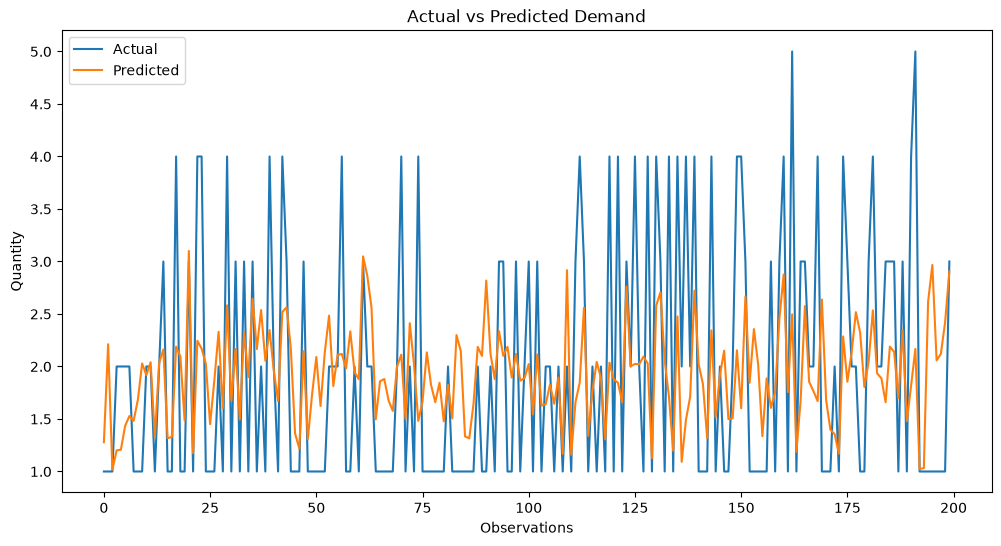

In [40]:
plt.figure(figsize=(12,6))

plt.plot(
    predictions["Actual"][:200],
    label="Actual"
)

plt.plot(
    predictions["Predicted"][:200],
    label="Predicted"
)

plt.title("Actual vs Predicted Demand")

plt.xlabel("Observations")

plt.ylabel("Quantity")

plt.legend()

plt.show()

# Residual Error

In [41]:
predictions["Residual"] = (

    predictions["Actual"]

    -

    predictions["Predicted"]

)

predictions.head()

,store_id,sku_id,category,channel,unit_price,discount_pct,stock_on_hand,reorder_point,safety_stock,year,...,is_weekend,lag_1,lag_7,lag_30,rolling_7,rolling_30,stock_gap,Actual,Predicted,Residual
0,19,1774,9,2,204.15,0.0,0.0,90.0,31.0,2025,...,0,1.0,2.0,1.0,1.285714,1.833333,-90.0,1,1.278429,-0.278429
1,20,2179,1,2,98.03,0.0,145.0,79.0,31.0,2025,...,0,3.0,2.0,1.0,2.428571,2.066667,66.0,1,2.212202,-1.212202
2,27,1774,9,0,204.15,0.0,0.0,0.0,0.0,2025,...,0,1.0,1.0,2.0,1.000000,1.766667,0.0,1,1.017757,-0.017757
3,11,1774,9,2,204.15,0.0,211.0,77.0,27.0,2025,...,0,1.0,1.0,4.0,1.142857,1.700000,134.0,2,1.201163,0.798837
4,0,1774,9,1,204.15,0.0,0.0,71.0,35.0,2025,...,0,2.0,1.0,1.0,1.285714,1.733333,-71.0,2,1.207672,0.792328


# Residual Distribution

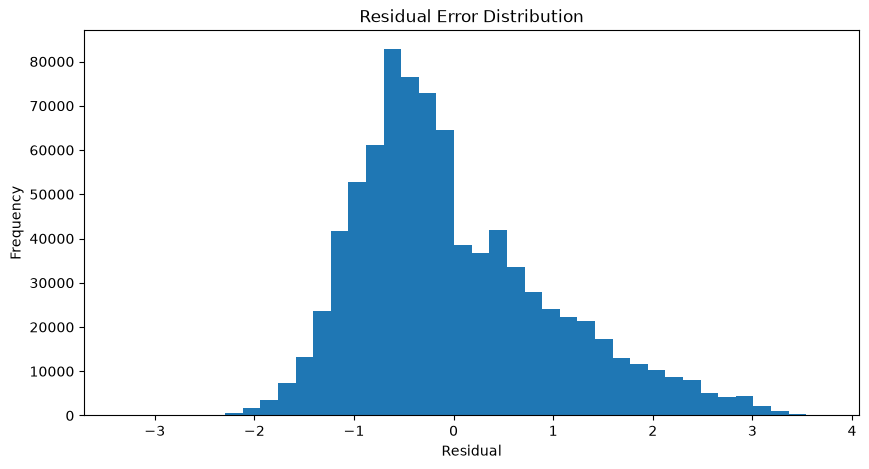

In [42]:
plt.figure(figsize=(10,5))

plt.hist(
    predictions["Residual"],
    bins=40
)

plt.title("Residual Error Distribution")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.show()

# RMSE Comparison

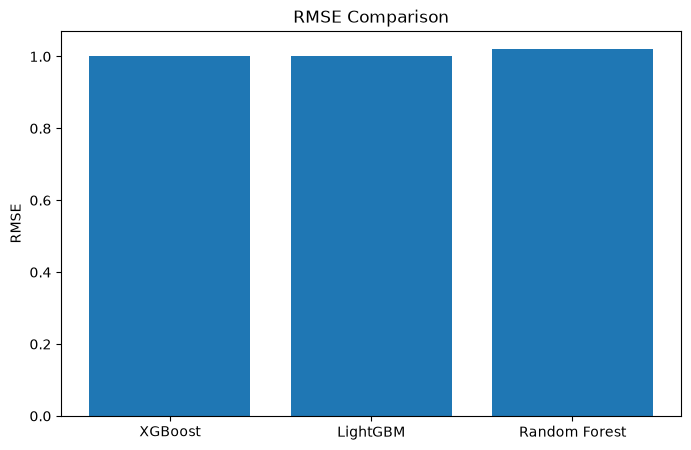

In [43]:
plt.figure(figsize=(8,5))

plt.bar(

    comparison["Model"],

    comparison["RMSE"]

)

plt.title("RMSE Comparison")

plt.ylabel("RMSE")

plt.show()

# MAE Comparison

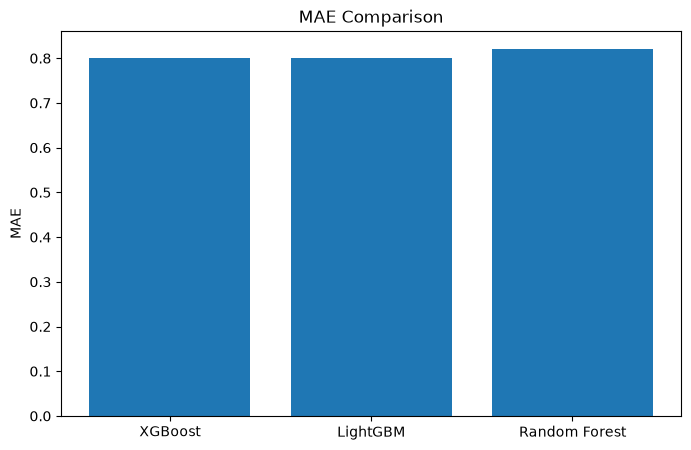

In [44]:
plt.figure(figsize=(8,5))

plt.bar(

    comparison["Model"],

    comparison["MAE"]

)

plt.title("MAE Comparison")

plt.ylabel("MAE")

plt.show()

# Save Evaluation Report

In [46]:
comparison.to_csv(
    "../reports/model_evaluation_report.csv",
    index=False
)

print("Model Evaluation Report Saved Successfully")

Model Evaluation Report Saved Successfully


# Phase Summary

### Completed Tasks

- Loaded prediction results
- Loaded model comparison results
- Ranked forecasting models
- Selected best forecasting model
- Visualized Actual vs Predicted demand
- Performed residual analysis
- Compared MAE and RMSE
- Saved the evaluation report

The best forecasting model is now ready for the next phase: **Risk Scoring**.